In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)
vgg_model.classifier[6] = nn.Linear(4096, 9)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 88.8MB/s]


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
cp -r /content/drive/MyDrive/Mushrooms /content/Mushrooms

In [8]:
for p in vgg_model.parameters():
    p.requires_grad = False
for p in my_model[0][17:24].parameters():
    p.requires_grad = False
for p in my_model[3:].parameters():  # Linear → ReLU → Dropout → Linear
    p.requires_grad = False
# Verify
trainable_count = sum(p.requires_grad for p in vgg_model.parameters())
print("Trainable params:", trainable_count)
print(any(p.requires_grad for p in vgg_model.parameters()))
print(sum(p.requires_grad for p in my_model.parameters()))



Trainable params: 0
False
0


In [7]:
N_CLASSES = 9
my_model = nn.Sequential(
    vgg_model.features,
    vgg_model.avgpool,
    nn.Flatten(),

    nn.Linear(25088, 256),
    nn.ReLU(),
    nn.Dropout(0.6)
)
my_model
print(type(my_model))


<class 'torch.nn.modules.container.Sequential'>


In [9]:
def split_decay(params):
    decay = []
    no_decay = []

    for p in params:
        if not p.requires_grad:
            continue

        if p.ndim == 1:          # bias or BatchNorm
            no_decay.append(p)
        else:                    # weights
            decay.append(p)

    return decay, no_decay

In [10]:
from torch.optim import AdamW
print(type(my_model))
weights_tensor = torch.ones(9).to(device)
weights_tensor[0] = 3.5
loss_function =nn.CrossEntropyLoss(weight=weights_tensor)
checkpoint = torch.load("/content/drive/MyDrive/final_model.pth", map_location=device)
state_dict=checkpoint["model_state_dict"]
filtered_state_dict = state_dict
my_model.load_state_dict(filtered_state_dict,strict=False)
my_model.to(device)

head_decay, head_no_decay = split_decay(my_model[3:].parameters())
vgg_decay, vgg_no_decay = split_decay(vgg_model.features[5:].parameters())
optimizer = torch.optim.AdamW(
    my_model[3:].parameters(),  # classifier head only
    lr=1e-5,
    weight_decay=1e-3
)

old_optimizer=checkpoint['optimizer_state_dict']
new_optimizer = optimizer.state_dict()
new_param_ids = set(new_optimizer['state'].keys())
filtered_state = {
    k: v for k, v in old_optimizer['state'].items()
    if k in new_param_ids
}
new_optimizer['state'] = filtered_state
optimizer.load_state_dict(new_optimizer)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

IMG_WIDTH, IMG_HEIGHT = (224, 224)


<class 'torch.nn.modules.container.Sequential'>


In [47]:

train_trans = transforms.Compose([
    transforms.Resize((224, 224)),# make smaller side 256
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(7),
    transforms.ColorJitter(
        brightness=0.07,
        contrast=0.09,
        saturation=0.05,
        hue=0.03
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.ToTensor(),# PIL -> tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # ImageNet mean
        std=[0.229, 0.224, 0.225]      # ImageNet std
    ),
])
valid_trans = transforms.Compose([
    transforms.Resize(256),   # make smaller side 256
    transforms.CenterCrop(224),  # crop exact 224x224
    transforms.ToTensor(),               # PIL -> tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # ImageNet mean
        std=[0.229, 0.224, 0.225]      # ImageNet std
    ),
])
test_trans = transforms.Compose([
    transforms.Resize(256),   # make smaller side 256
    transforms.CenterCrop(224),  # crop exact 224x224
    transforms.ToTensor(),               # PIL -> tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # ImageNet mean
        std=[0.229, 0.224, 0.225]      # ImageNet std
    ),
])
agaricus_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.3, saturation=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAdjustSharpness(sharpness_factor=3, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
boletus_aug = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.6, saturation=0.3),
    transforms.RandomRotation(30),
    transforms.RandomAdjustSharpness(sharpness_factor=3, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
import os
print(type(my_model))

<class 'torch.nn.modules.container.Sequential'>


In [35]:
import os
import random
from collections import defaultdict
from PIL import Image,ImageFile
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torch import Generator
from torch.utils.data import DataLoader
import shutil
dataset_path = "/content/Mushrooms"
ImageFile.LOAD_TRUNCATED_IMAGES = True
preprocessed_path = "/content/Mushrooms_preprocess"
os.makedirs(preprocessed_path, exist_ok=True)
classes = sorted(os.listdir(dataset_path))
for cls in classes:
    src_class_path = os.path.join(dataset_path, cls)
    dst_class_path = os.path.join(preprocessed_path, cls)
    os.makedirs(dst_class_path, exist_ok=True)
    for img_name in os.listdir(src_class_path):
        src_img_path = os.path.join(src_class_path, img_name)
        dst_img_path = os.path.join(dst_class_path, img_name)
        try:
            img = Image.open(src_img_path).convert("RGB")  # try loading
            img.save(dst_img_path)
        except Exception:
           print(f"Replaced corrupted image with dummy:")
images_by_class = defaultdict(list)
for cls in classes:
    cls_path = os.path.join(preprocessed_path, cls)
    for img_name in os.listdir(cls_path):
        images_by_class[cls].append(os.path.join(cls_path, img_name))
random.seed(42)
selected_images_by_class = {}
for cls, imgs in images_by_class.items():
    selected_images_by_class[cls] = random.sample(imgs, min(300, len(imgs)))
all_selected_images = []
all_labels = []
for label, cls in enumerate(classes):
    imgs = selected_images_by_class[cls]
    all_selected_images.extend(imgs)
    all_labels.extend([label]*len(imgs))
print(type(my_model))

<class 'torch.nn.modules.container.Sequential'>


In [48]:
class MushroomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if label == 0:  # Agaricus index
            img = agaricus_aug(img)
       # elif label==2:
       #     img = boletus_aug(img)
        elif self.transform:
            img = self.transform(img)

        return img, label

class CNNFeatureExtractor(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        return x

In [37]:
def extract_features(model, dataloader, device):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            feats = model(x)
            features.append(feats.cpu().numpy())
            labels.append(y.numpy())

    return np.vstack(features), np.hstack(labels)

In [55]:
x, _ = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    feats = my_model(x)

print(feats.shape)

torch.Size([35, 256])


In [56]:
import numpy as np
X_train, y_train = extract_features(my_model, train_loader, device)
X_val,   y_val   = extract_features(my_model, valid_loader, device)
X_test,  y_test  = extract_features(my_model, test_loader, device)

In [57]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(1889, 256) (1889,)
(540, 256) (540,)
(271, 256) (271,)


In [376]:
from sklearn.svm import SVC
#weights = {0:2,1:1,2:3,3:1,4:4,5:2,6:2,7:0.9,8:0.9}
weights = {0:0.8,1:1,2:1,3:1,4:0.6,6:0.8,7:0.6,8:0.5}
svm = SVC(
    kernel="linear",
    C=0.001,
    class_weight=weights,
    decision_function_shape="ovr"
)

svm.fit(X_train, y_train)

SVC(C=0.001,
    class_weight={0: 0.8, 1: 1, 2: 1, 3: 1, 4: 0.6, 6: 0.8, 7: 0.6, 8: 0.5},
    kernel='linear')

In [377]:
print("Train acc:", svm.score(X_train, y_train))
print("Val acc:", svm.score(X_val, y_val))
print("Test acc:", svm.score(X_test, y_test))

Train acc: 0.8570672313393329
Val acc: 0.8759259259259259
Test acc: 0.9114391143911439


In [378]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.88      0.92      0.90        25
           2       0.97      0.92      0.94        36
           3       0.85      0.82      0.84        34
           4       0.96      0.90      0.93        30
           5       1.00      1.00      1.00        28
           6       0.82      0.79      0.81        29
           7       0.70      0.88      0.78        24
           8       1.00      1.00      1.00        28

    accuracy                           0.91       271
   macro avg       0.91      0.91      0.91       271
weighted avg       0.92      0.91      0.91       271



In [379]:
import joblib

joblib.dump(svm, "svm_linear_mushrooms.joblib")

['svm_linear_mushrooms.joblib']

In [49]:


dataset = MushroomDataset(all_selected_images, all_labels, transform=None)
generator = Generator().manual_seed(42)
n_total = len(dataset)
n_train = int(0.7 * n_total)
n_valid = int(0.2 * n_total)
n_test = n_total - n_train - n_valid

train_subset, valid_subset, test_subset = random_split(
    dataset, [n_train, n_valid, n_test], generator=generator
)
print(type(my_model))
print(len(test_subset))

<class 'torch.nn.modules.container.Sequential'>
271


In [50]:
def subset_to_dataset(subset, transform):
    images = [subset.dataset.image_paths[i] for i in subset.indices]
    labels = [subset.dataset.labels[i] for i in subset.indices]
    return MushroomDataset(images, labels, transform=transform)
train_dataset=subset_to_dataset(train_subset,train_trans)
valid_dataset=subset_to_dataset(valid_subset,valid_trans)
test_dataset=subset_to_dataset(test_subset,test_trans)

In [51]:
batch_size = 35

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(type(my_model))

<class 'torch.nn.modules.container.Sequential'>


In [52]:
n_epochs = 20
print(type(my_model))
from collections import Counter

label_counts = Counter(all_labels)  # or train labels only
num_classes = len(label_counts)

class_weights = torch.zeros(num_classes)

for cls, count in label_counts.items():
    class_weights[cls] = 1.0 / count

# normalize (important)
class_weights = class_weights / class_weights.sum() * num_classes
loss_function=nn.CrossEntropyLoss(weight=class_weights.to(device))

<class 'torch.nn.modules.container.Sequential'>


In [53]:
from typing import Callable, Optional, Tuple
def train_one_epoch(
    model: torch.nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: torch.nn.Module,
    device: torch.device,
    batch_transform: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    log_interval: int = 100
) -> Tuple[float, float]:
    """
    Train model for one epoch.
    Returns: (epoch_loss, epoch_acc) where acc is in [0,1].
    - batch_transform: optional callable applied to the image batch BEFORE .to(device).
      Use this if you want to apply augmentations on the fly (not required if transforms are in the Dataset).
    - log_interval: how many batches between small progress prints (0 disables).
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        # optional on-the-fly transform (applied while still on CPU typically)
        if batch_transform is not None:
            images = batch_transform(images)

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)                 # raw logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        if log_interval and (batch_idx + 1) % log_interval == 0:
            avg_loss = running_loss / total
            acc = correct / total
            print(f'  Batch {batch_idx+1}/{len(loader)} — loss: {avg_loss:.4f}, acc: {acc:.4f}')

    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc
print(type(my_model))

<class 'torch.nn.modules.container.Sequential'>


In [54]:
def validate(
    model: torch.nn.Module,
    loader: DataLoader,
    criterion: torch.nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """
    Evaluate model on validation/test set. Returns (loss, acc).
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size

    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc
print(type(my_model))

<class 'torch.nn.modules.container.Sequential'>


In [45]:
best_val_loss = float('inf')
best_val_loss = checkpoint["val_loss"]
n_epochs=5
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")

    # ---- TRAIN ----
    train_loss, train_acc = train_one_epoch(
        model=my_model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=loss_function,
        device=device,
        batch_transform=None,   # keep None if Dataset has transforms
        log_interval=9         # adjust for more frequent printing
    )

    val_loss, val_acc = validate(
        model=my_model,
        loader=valid_loader,
        criterion=loss_function,
        device=device
    )
    print(f"  Train — loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"  Valid — loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    print(f"Current LR: {[group['lr'] for group in optimizer.param_groups]}")

    # ---- OPTIONAL: SAVE BEST MODEL ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state_dict": my_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss
        }, "best_model_checkpoint.pth")
        print("  Saved best_model_checkpoint.pth")


Epoch 1/5


RuntimeError: stack expects each tensor to be equal size, but got [3, 256, 371] at entry 0 and [3, 256, 332] at entry 1

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix
def test_model(model, test_loader, device, criterion=None):
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():  # ensures no gradients
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

            if criterion is not None:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)

    acc = accuracy_score(all_targets, all_preds)
    avg_loss = total_loss / len(test_loader.dataset) if criterion else None
    cm = confusion_matrix(all_targets, all_preds)
    misclassified_idx = [i for i, (p, t) in enumerate(zip(all_preds, all_targets)) if p != t]
    print("Misclassified sample indices:", misclassified_idx)

    # Map indices to true/pred labels and image path
    misclassified_info = []
    for idx in misclassified_idx:
        true_label = dataset.labels[idx]
        pred_label = all_preds[idx]
        img_path = dataset.image_paths[idx]
        misclassified_info.append((idx, true_label, pred_label, img_path))

    print("Misclassified samples (index, true label, predicted label, file path):")
    for info in misclassified_info:
        print(info)

    return {"accuracy": acc, "loss": avg_loss, "confusion_matrix": cm, "misclassified": misclassified_info}

In [22]:
test_results = test_model(my_model, test_loader, device, loss_function)
print(f"Test Accuracy: {test_results['accuracy']:.4f}")
if test_results['loss'] is not None:
    print(f"Test Loss: {test_results['loss']:.4f}")
print("Confusion Matrix:")
print(test_results["confusion_matrix"])

Misclassified sample indices: [6, 19, 28, 34, 46, 50, 53, 66, 71, 82, 88, 91, 98, 104, 115, 117, 123, 135, 137, 154, 159, 161, 169, 188, 191, 193, 209, 238, 252]
Misclassified samples (index, true label, predicted label, file path):
(6, 0, np.int64(5), '/content/Mushrooms_preprocess/Agaricus/319_E8n5Pf7d8Vc.jpg')
(19, 0, np.int64(8), '/content/Mushrooms_preprocess/Agaricus/107_nHRf0ZG2NHs.jpg')
(28, 0, np.int64(3), '/content/Mushrooms_preprocess/Agaricus/269_WpXmhjgjIeQ.jpg')
(34, 0, np.int64(7), '/content/Mushrooms_preprocess/Agaricus/087_S8PN799v2qs.jpg')
(46, 0, np.int64(1), '/content/Mushrooms_preprocess/Agaricus/091_3BEGnmvAiRw.jpg')
(50, 0, np.int64(8), '/content/Mushrooms_preprocess/Agaricus/016_qNYODERZEms.jpg')
(53, 0, np.int64(7), '/content/Mushrooms_preprocess/Agaricus/388_T-pbnIiXSkw.jpg')
(66, 0, np.int64(1), '/content/Mushrooms_preprocess/Agaricus/124_CKOidhx1oZ0.jpg')
(71, 0, np.int64(6), '/content/Mushrooms_preprocess/Agaricus/001_2jP9N_ipAo8.jpg')
(82, 0, np.int64(7), 

In [381]:
checkpoint = {
    "model_state_dict": my_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),# if you have it,                 # optional
    "num_classes": 9
}

torch.save(checkpoint, "/content/final_svm_model.pth")

In [ ]:
my_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = my_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_targets, all_preds)
print(cm)

[[47  4  0  2  2  0  0  3  0]
 [ 0 48  0  0  0  1  0  1  0]
 [ 0  0 48  1  1  0  1  0  4]
 [ 1  3  0 57  6  1  5  2  2]
 [ 3  4  0  3 47  3  1  4  0]
 [ 0  0  0  0  4 63  1  1  0]
 [ 0  1  0  5  2  0 43  4  2]
 [ 1  2  1  2  0  0  3 50  0]
 [ 1  1  1  2  1  0  0  1 43]]


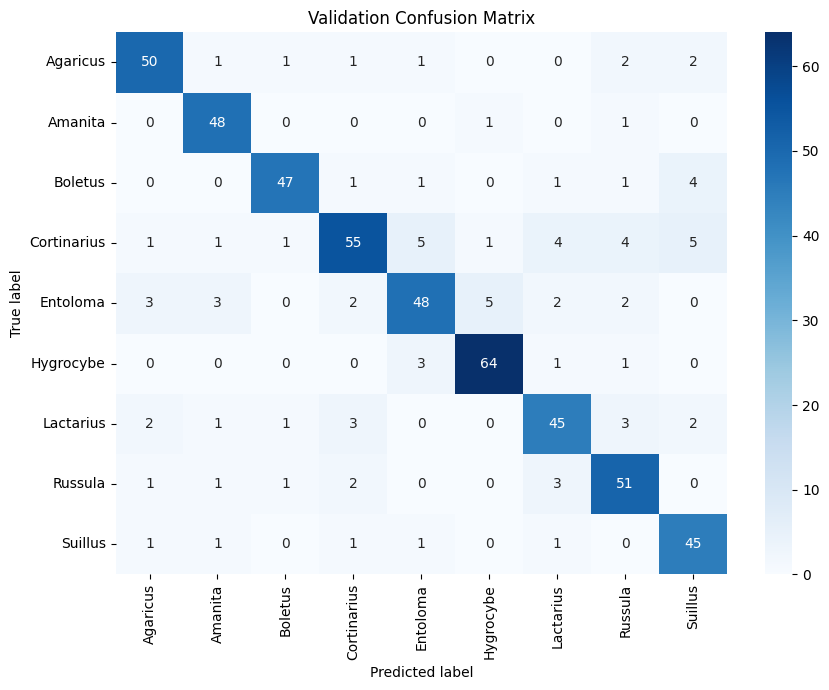

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = classes  # list of your 9 mushroom genera

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

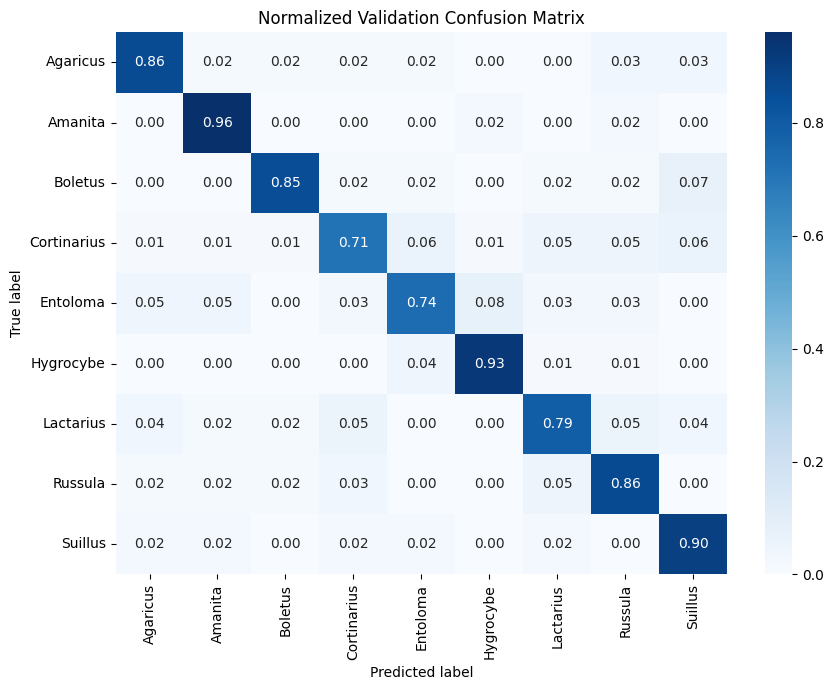

In [ ]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Validation Confusion Matrix")
plt.tight_layout()
plt.show()